In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from transformers import DropColumns,feature_ordinal_encoding

In [2]:
train = pd.read_csv('../Data/train.csv')
test = pd.read_csv('../Data/test.csv')

## 📋 Dataset Column Descriptions

| Category | Column Name | Description |
|--------|------------|-------------|
| Identifier | `id` | Unique identifier for each property |
| Sale Info | `date` | Date when the property was sold |
| Price | `price` | Final sale price of the house |
| Property Features | `bedrooms` | Number of bedrooms in the house |
| Property Features | `bathrooms` | Number of bathrooms (including partial bathrooms as fractions) |
| Property Features | `sqft_living` | Total living area in square feet |
| Property Features | `sqft_lot` | Total lot size in square feet |
| Property Features | `floors` | Number of floors in the house |
| Property Features | `waterfront` | Indicates whether the property has a waterfront view |
| Property Features | `view` | Quality rating of the property's view |
| Property Features | `condition` | Overall condition rating of the house |
| Property Features | `grade` | Construction and design quality (scale: 1–13) |
| Additional Metrics | `sqft_above` | Living area above ground level (in sq. ft.) |
| Additional Metrics | `sqft_basement` | Basement area in square feet |
| Additional Metrics | `yr_built` | Year the house was originally constructed |
| Additional Metrics | `yr_renovated` | Year of the most recent renovation (0 if never renovated) |
| Location | `zipcode` | ZIP code of the property |
| Location | `lat` | Latitude coordinate |
| Location | `long` | Longitude coordinate |
| Neighbor Stats | `sqft_living15` | Average living area of the 15 nearest neighboring properties |
| Neighbor Stats | `sqft_lot15` | Average lot size of the 15 nearest neighboring properties |


In [3]:
train.sample(5)

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
10820,7214710210,20141217T000000,4,2.25,2380,36446,2.0,N,0,Good,...,2380,0,1977,0,98077,47.7644,-122.072,2790,40005,570000.0
4732,2113700485,20141210T000000,5,2.75,1690,4000,1.0,N,0,Very Good,...,970,720,1943,0,98106,47.5312,-122.354,1240,4000,399990.0
13126,8818400340,20150423T000000,4,3.00,2490,4325,1.5,N,0,Average,...,1690,800,1922,2003,98105,47.6628,-122.326,1960,4284,1081000.0
5317,1087700030,20140619T000000,3,1.75,1610,11200,1.0,N,0,Average,...,1610,0,1955,0,98033,47.6641,-122.176,1610,11200,450000.0
2538,2613200025,20150313T000000,2,1.00,1330,28270,1.5,N,0,Average,...,1330,0,1925,0,98168,47.4824,-122.274,1210,6926,175000.0


In [4]:
dataPipe = Pipeline([
    ('encode',feature_ordinal_encoding()),
    ('drop',DropColumns(cols=['id','date','zipcode']))
])

In [5]:
train_tsf = dataPipe.fit_transform(train)
test_tsf = dataPipe.transform(test)

In [6]:
train_tsf.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,price
0,4,2.75,2600,2750,1.5,0,0,2,7,1620,980,1936,0,47.6413,-122.357,1960,3705,840000.0
1,3,2.50,2140,9492,2.0,0,0,2,8,2140,0,1994,0,47.3289,-122.204,2180,9184,302000.0
2,4,1.75,1730,11890,1.0,0,0,1,7,980,750,1955,0,47.5979,-122.194,2100,12325,425000.0
3,4,2.50,2130,4496,2.0,0,0,2,7,2130,0,2004,0,47.3041,-122.280,3220,5400,215000.0
4,5,1.75,1910,9720,1.0,0,0,3,7,1390,520,1955,0,47.5772,-122.159,1750,9720,565000.0


In [7]:
train_tsf.describe()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,price
count,14480.000000,14480.000000,14480.000000,1.448000e+04,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,1.448000e+04
mean,3.367680,2.113225,2075.768439,1.505100e+04,1.499033,0.006906,0.231423,2.410152,7.653177,1786.859185,288.909254,1971.083702,82.410566,47.560850,-122.214365,1983.502348,12809.173412,5.377890e+05
std,0.935538,0.766134,909.091142,3.980053e+04,0.542292,0.082818,0.758018,0.651366,1.172298,826.407904,439.209514,29.387281,397.088523,0.138598,0.140063,682.589466,27273.288544,3.569339e+05
min,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,0.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,47.159300,-122.519000,399.000000,651.000000,7.500000e+04
25%,3.000000,1.500000,1420.000000,5.008750e+03,1.000000,0.000000,0.000000,2.000000,7.000000,1200.000000,0.000000,1951.000000,0.000000,47.472200,-122.329000,1483.250000,5100.000000,3.220000e+05
50%,3.000000,2.250000,1910.000000,7.574000e+03,1.500000,0.000000,0.000000,2.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,47.573100,-122.232000,1840.000000,7606.500000,4.500000e+05
75%,4.000000,2.500000,2550.000000,1.064050e+04,2.000000,0.000000,0.000000,3.000000,8.000000,2200.000000,560.000000,1997.000000,0.000000,47.678425,-122.125000,2360.000000,10070.000000,6.400000e+05
max,33.000000,8.000000,12050.000000,1.164794e+06,3.500000,1.000000,4.000000,4.000000,13.000000,8860.000000,4820.000000,2015.000000,2015.000000,47.777600,-121.315000,6210.000000,871200.000000,7.700000e+06


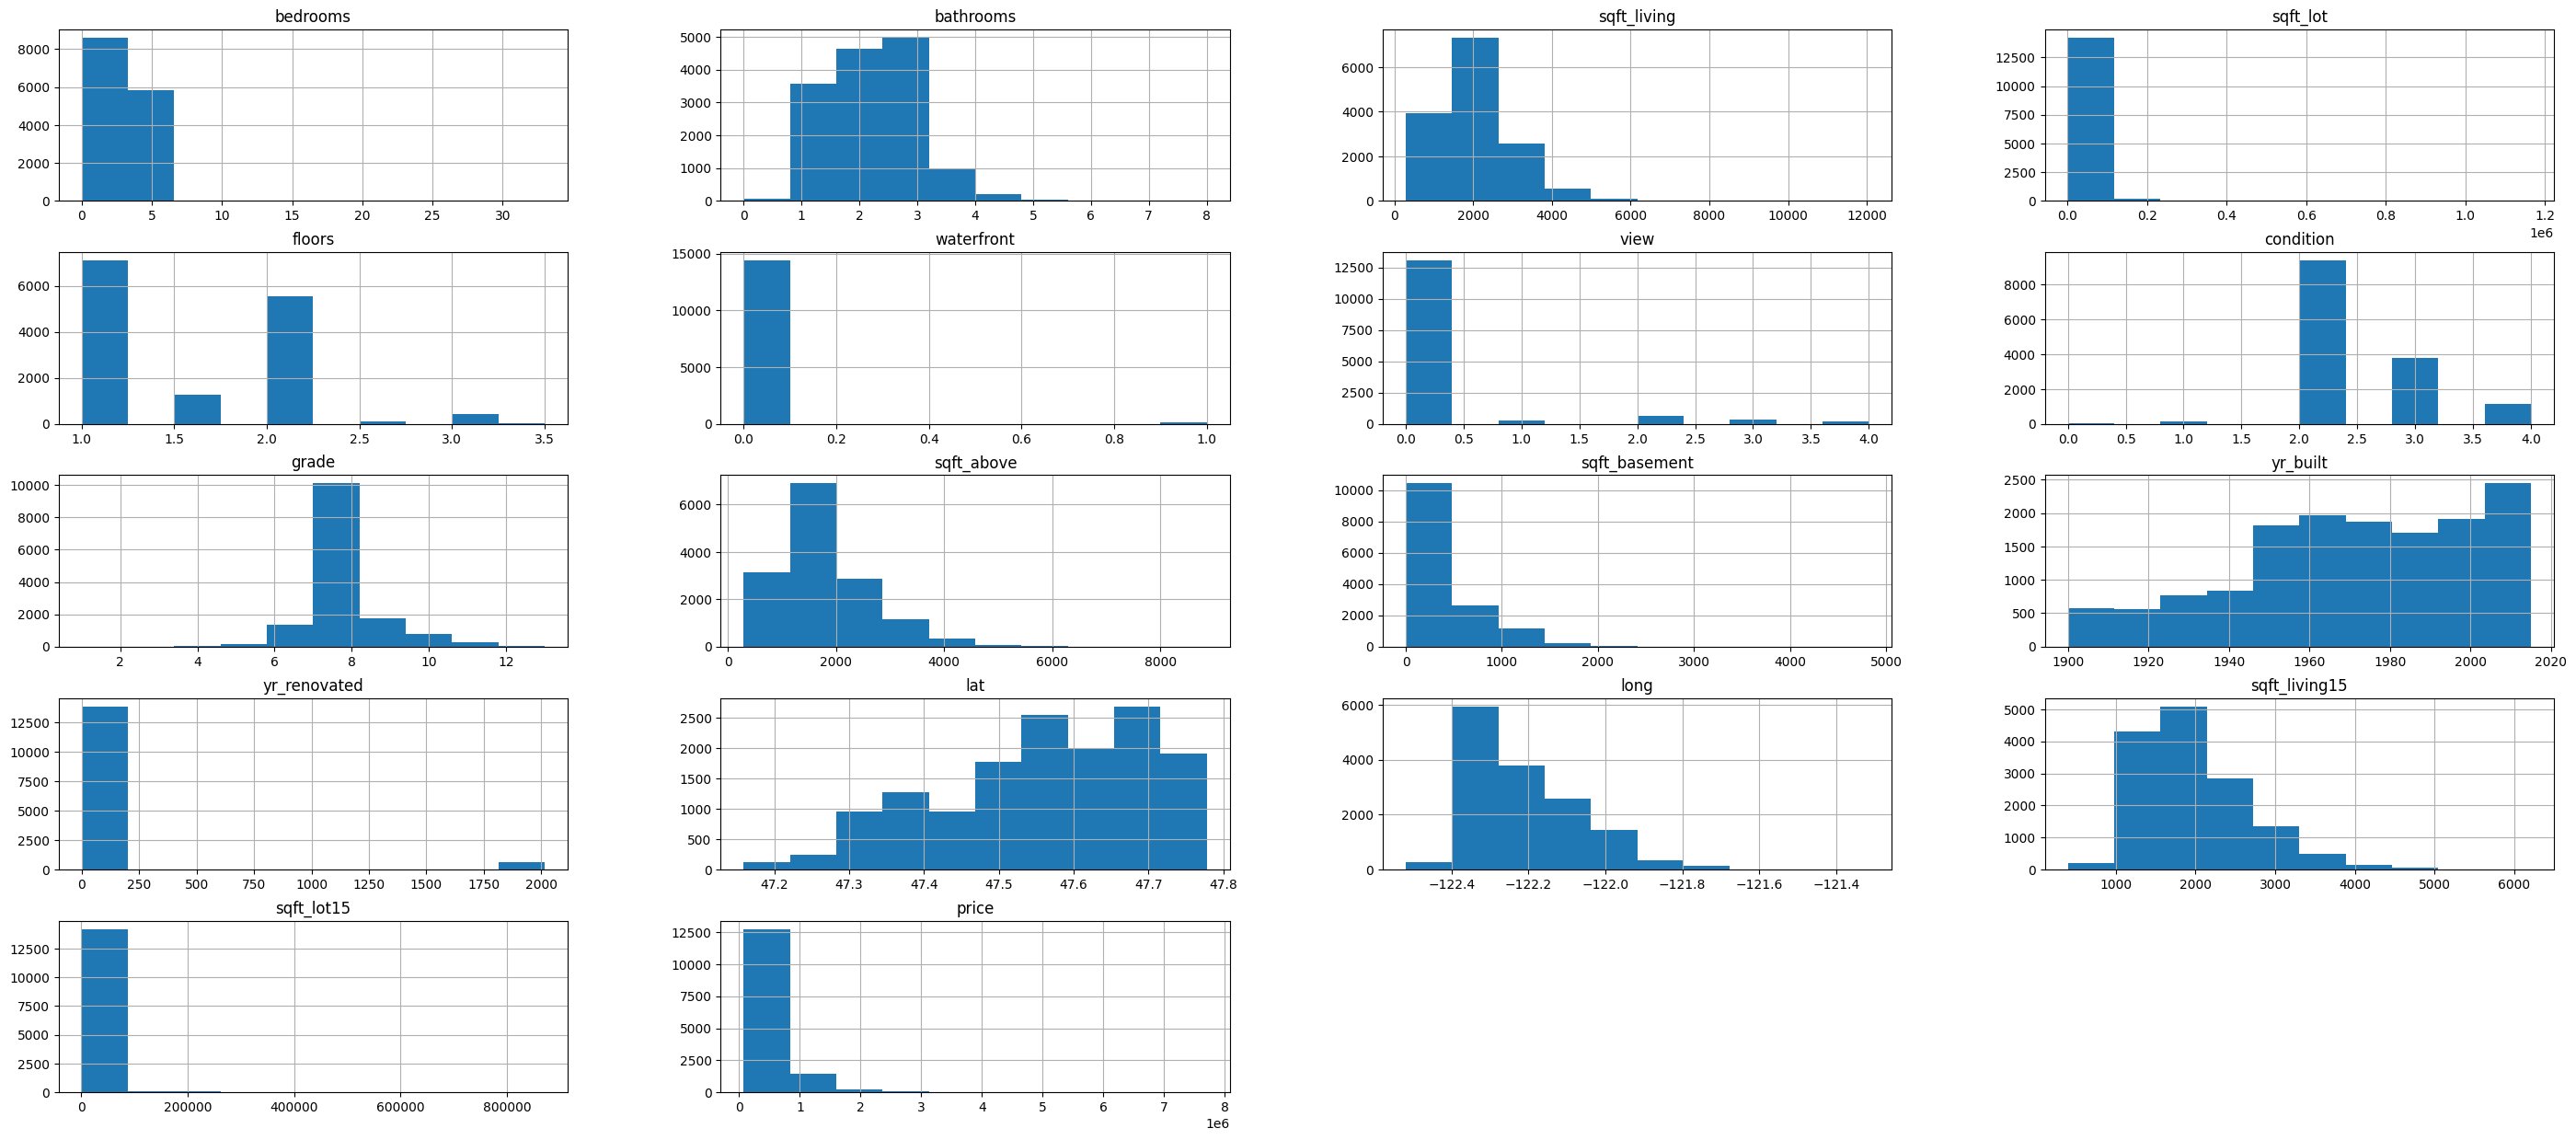

In [8]:
train_tsf.hist(figsize=(35,15))
plt.show()

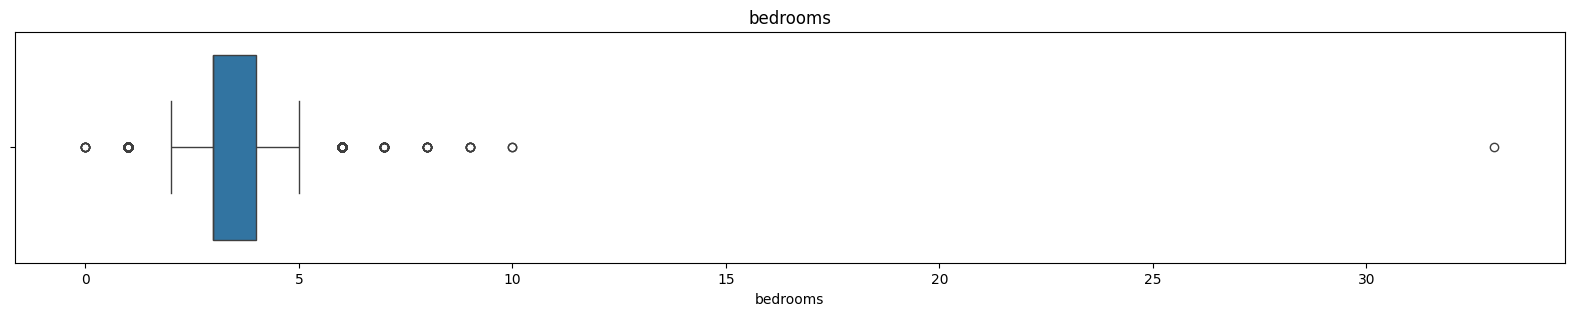

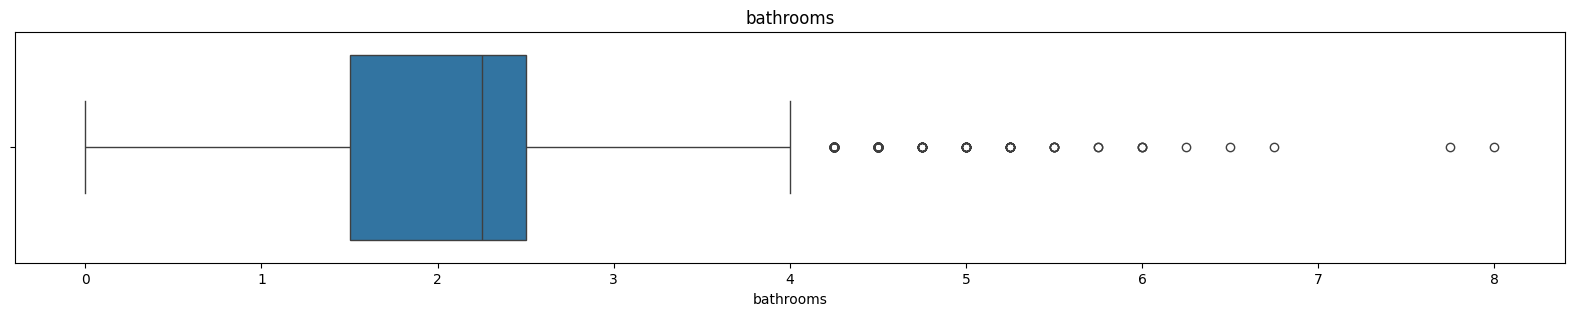

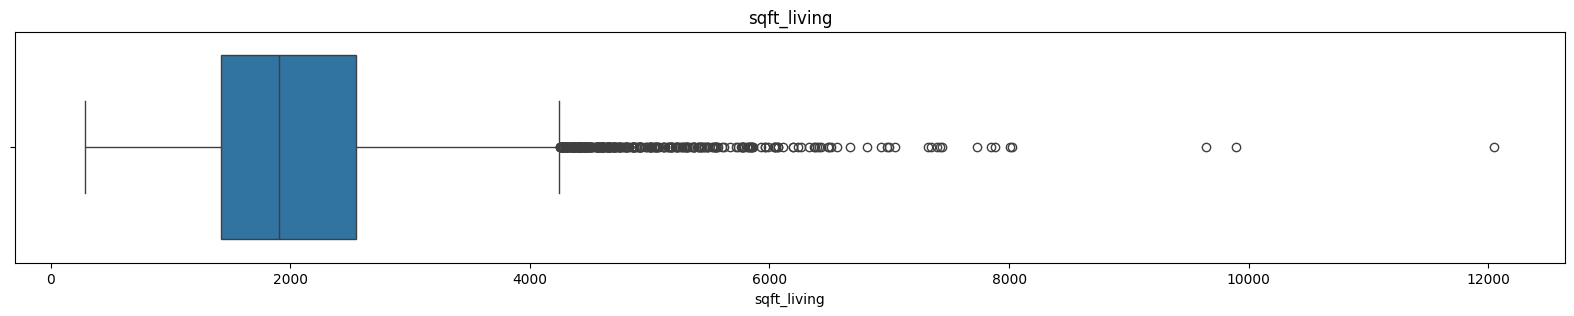

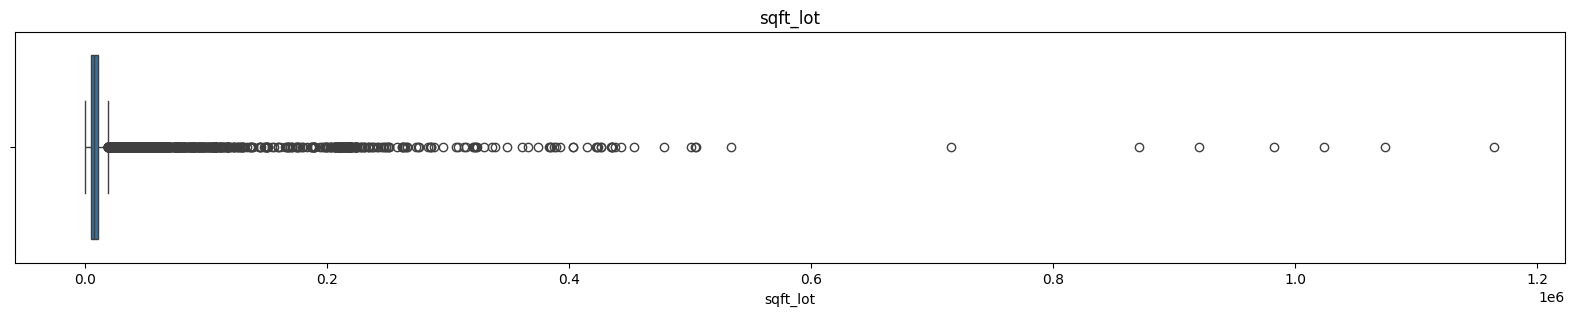

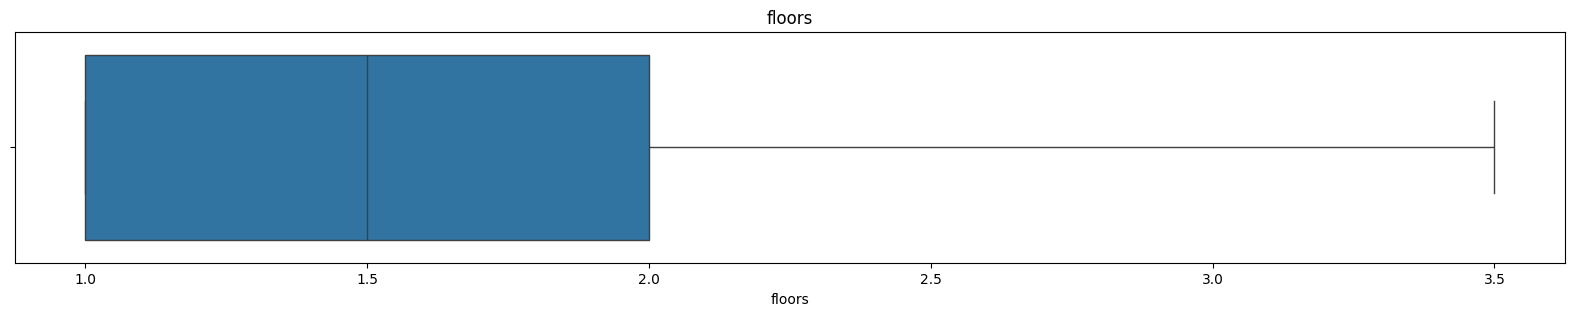

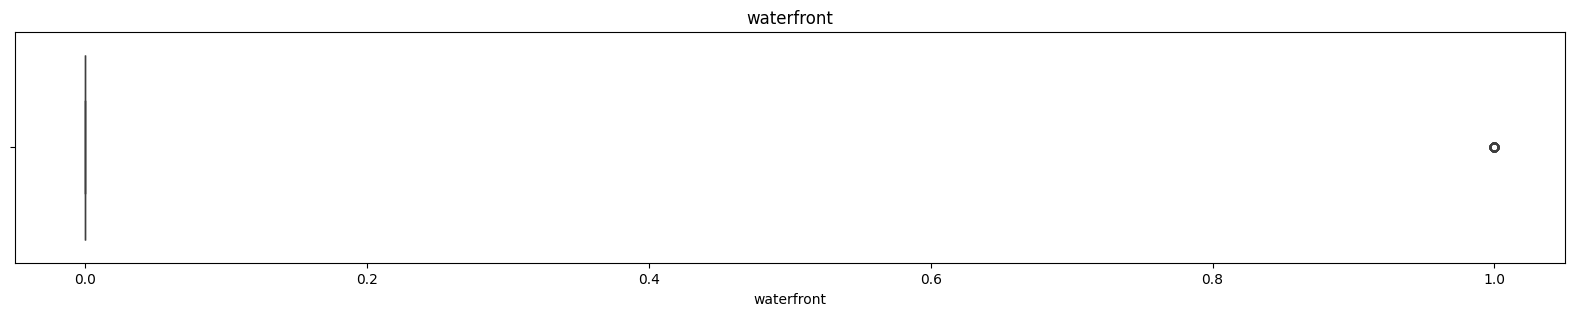

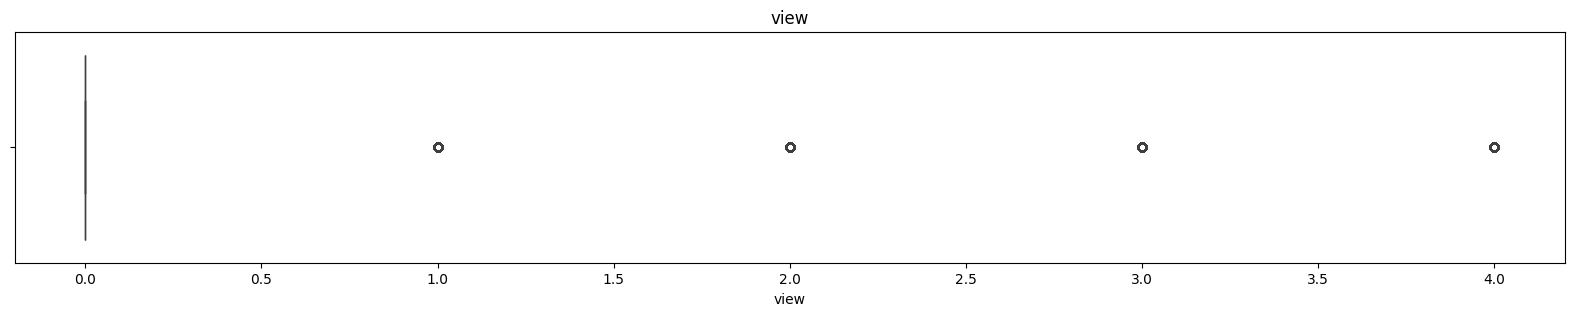

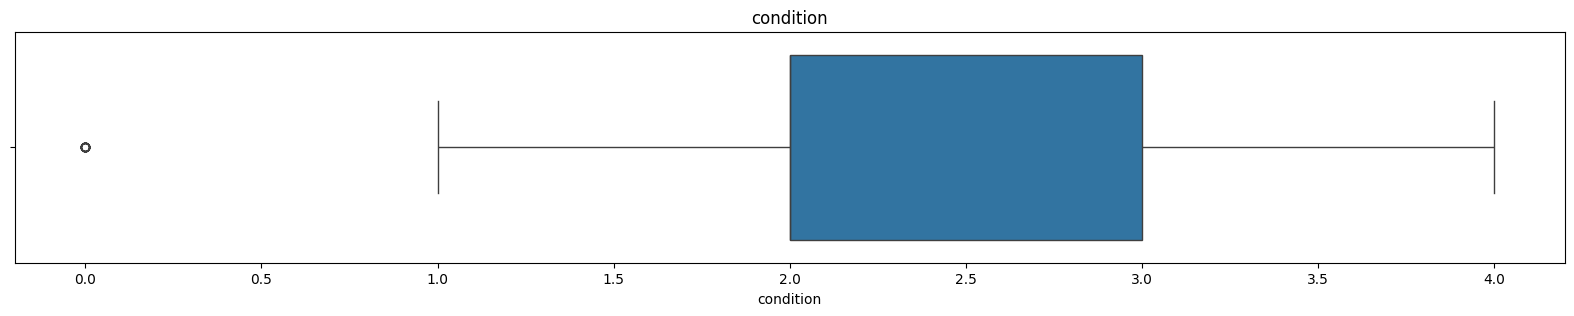

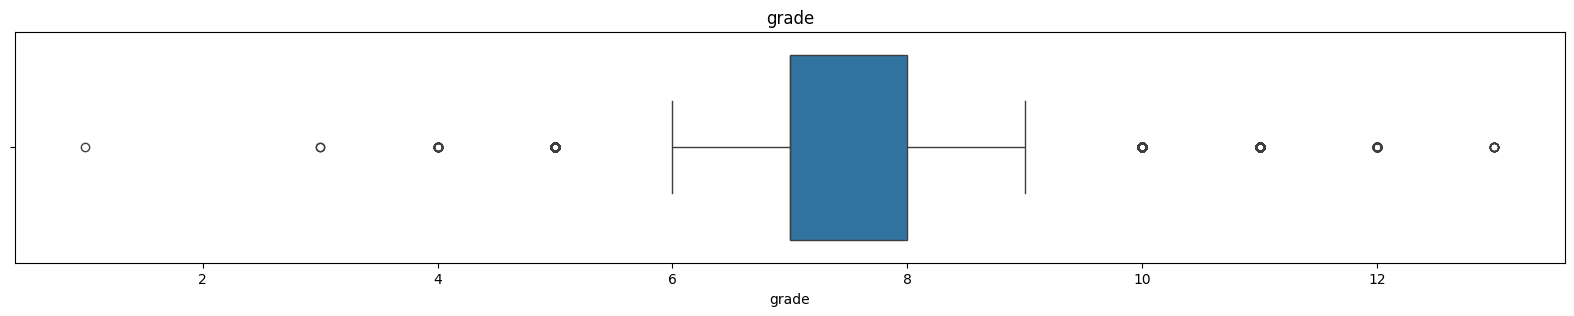

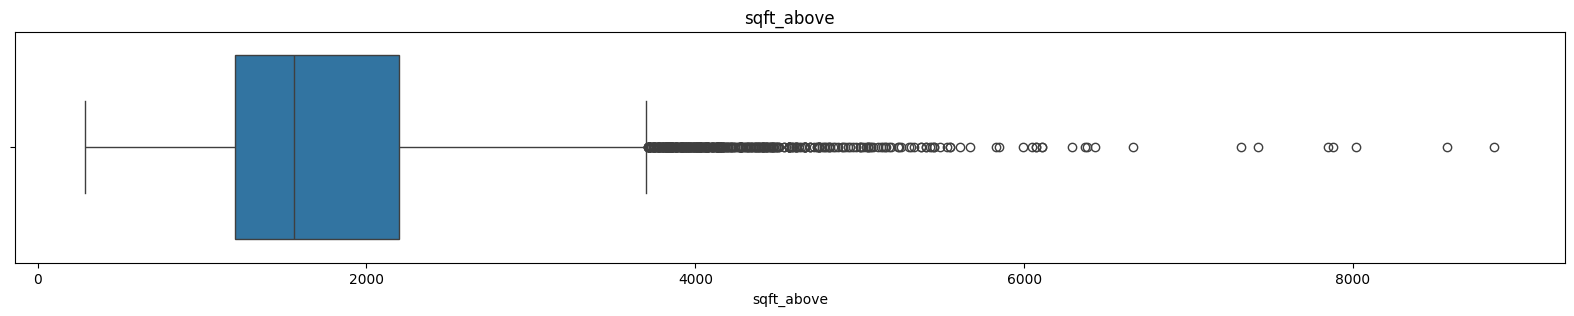

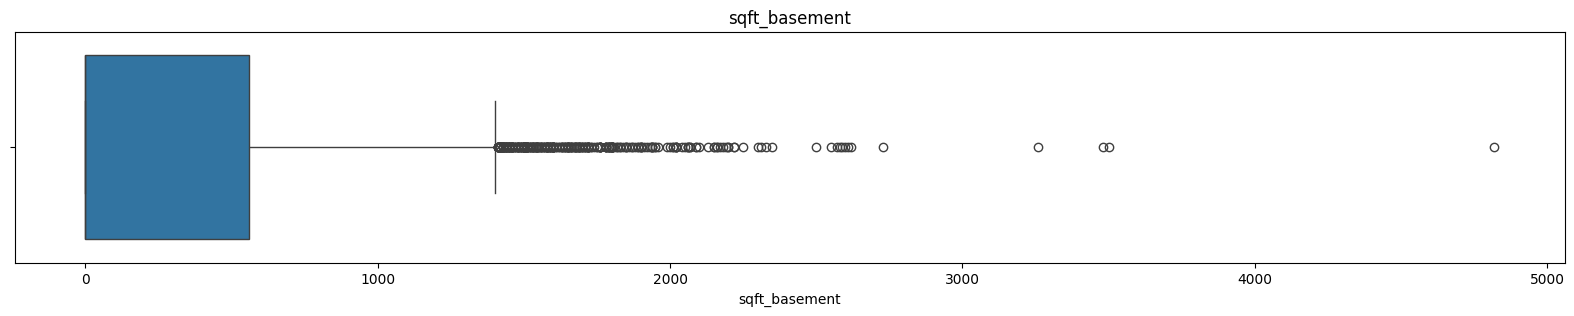

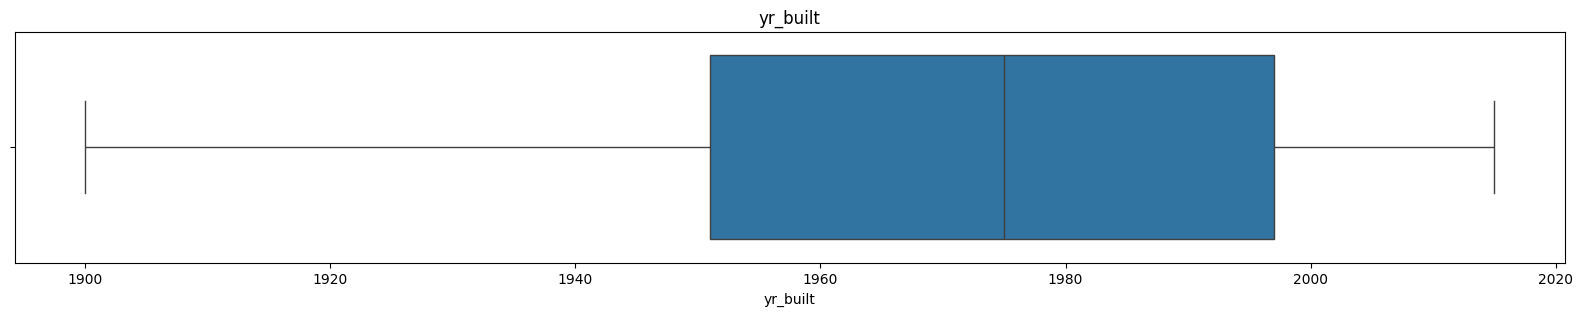

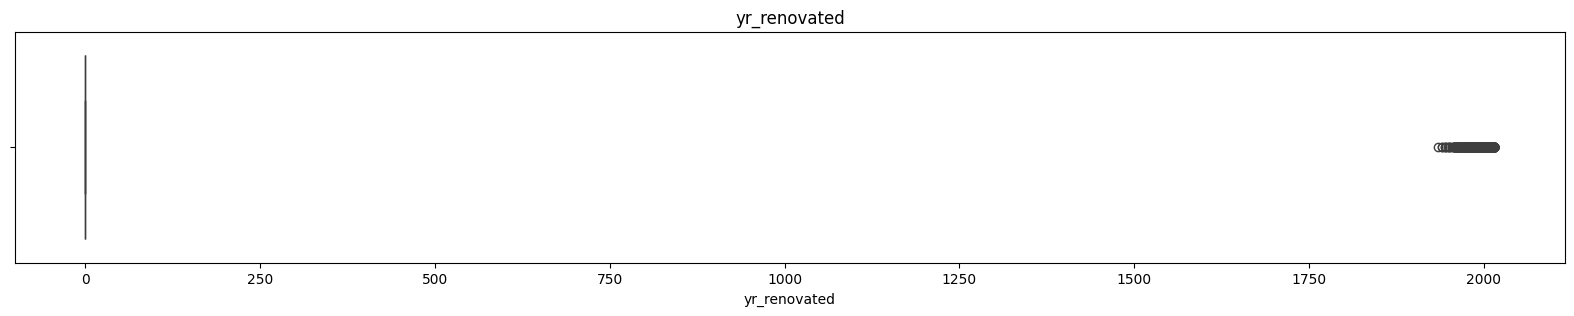

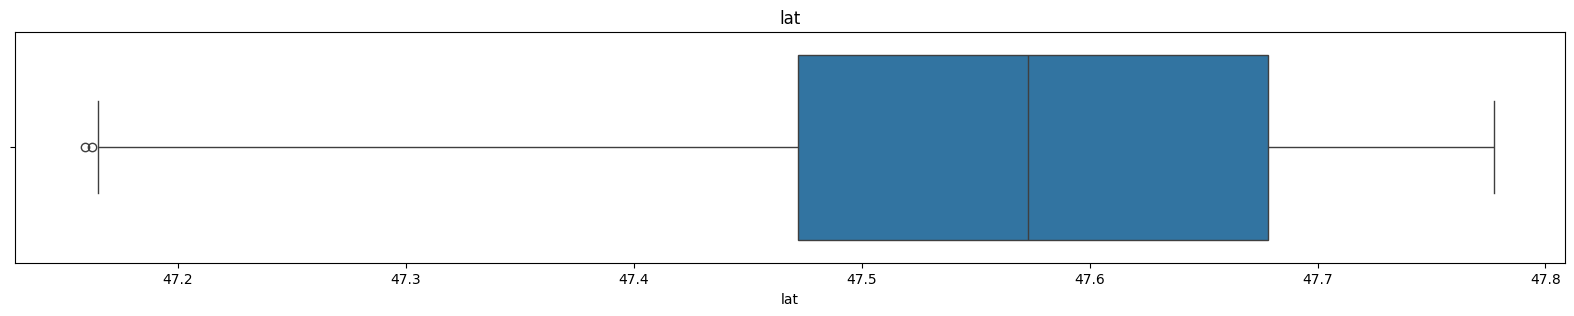

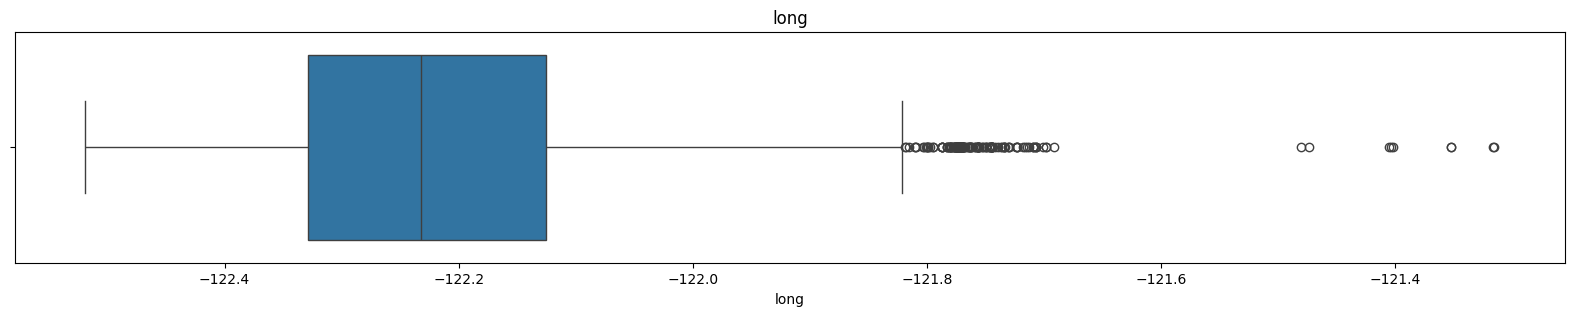

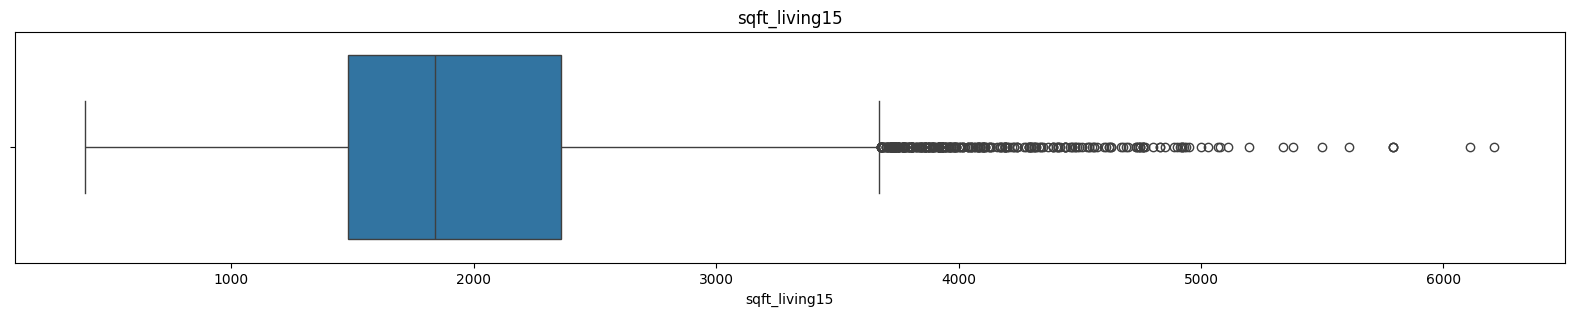

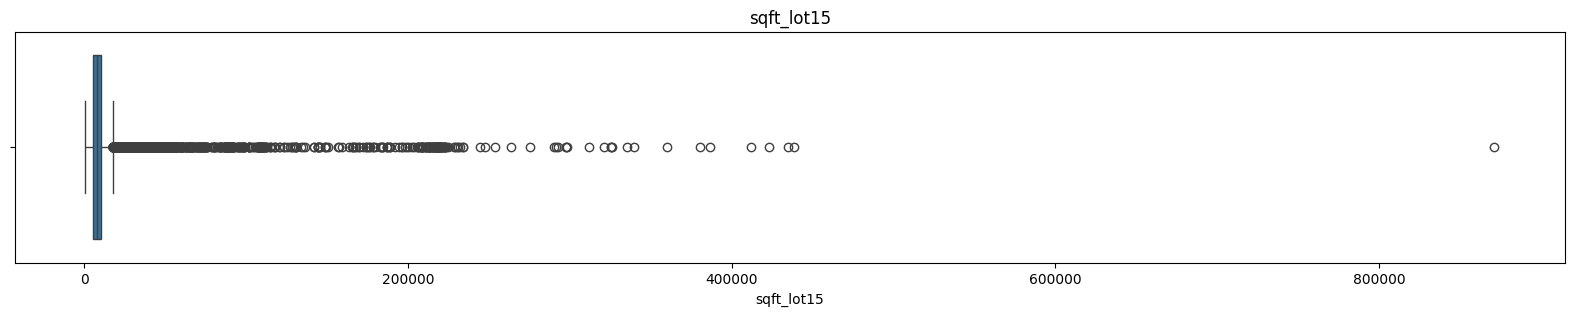

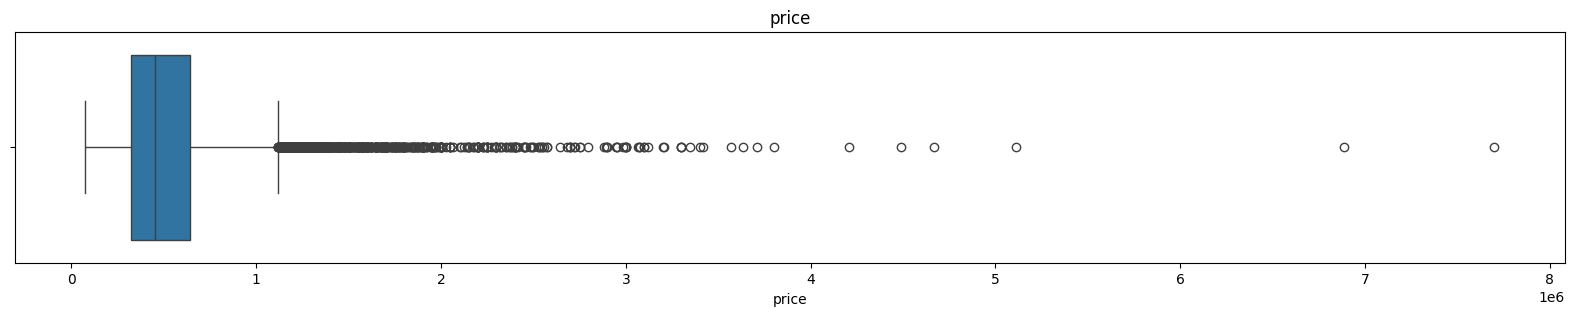

In [9]:
for col in train_tsf.columns:
    plt.figure(figsize=(20,3))
    sns.boxplot(x=train_tsf[col]).set_title(col)
    plt.show()

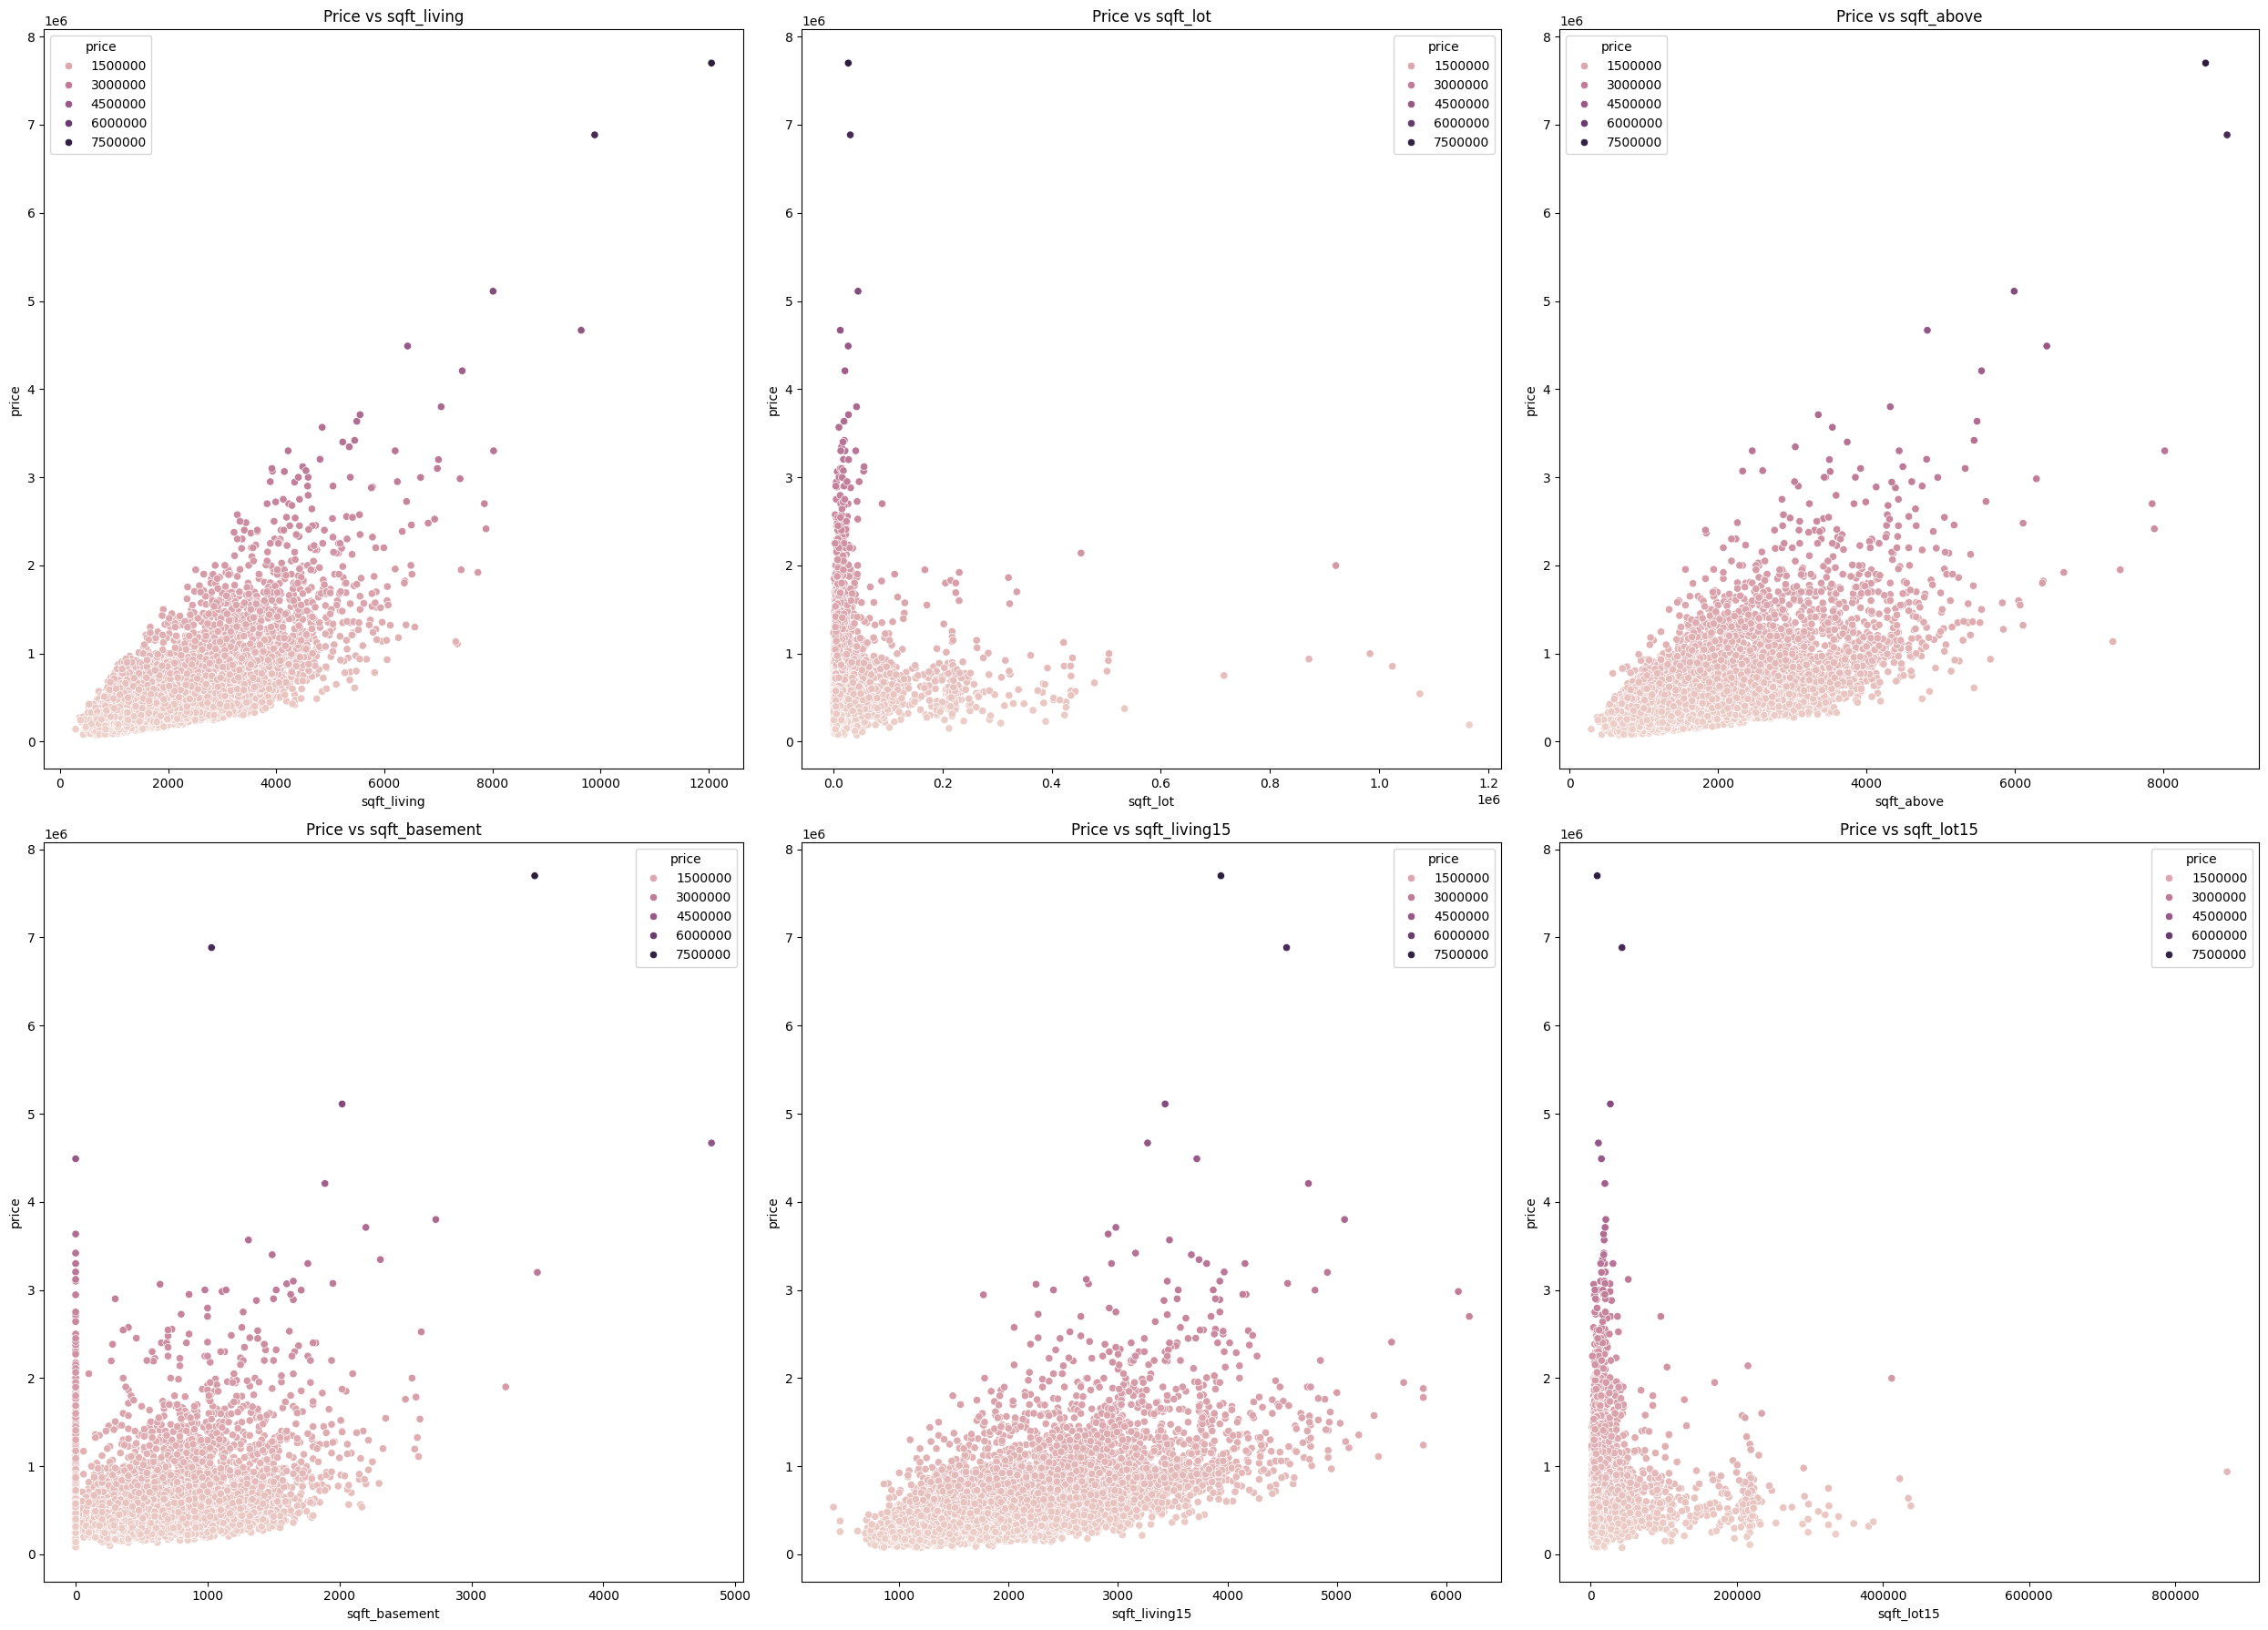

In [10]:
fig,axes= plt.subplots(2,3,figsize=(25,18))
ax = axes.flatten()
price_vs_cols = ['sqft_living','sqft_lot','sqft_above','sqft_basement','sqft_living15','sqft_lot15']
for ax,col in zip(ax,price_vs_cols):
    sns.scatterplot(train_tsf,x=col,y='price',hue='price',ax=ax).set_title(f"Price vs {col}")
plt.tight_layout()
plt.show()

In [11]:
print(train_tsf.info())
print(f"""
Null count: {train_tsf.isnull().sum().sum()}

duplicates count : {train_tsf.duplicated().sum()}
""")
print('+-'*30)
print(test_tsf.info())
print(f"""
Null count: {test_tsf.isnull().sum().sum()}

duplicates count : {test_tsf.duplicated().sum()}
""")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14480 entries, 0 to 14479
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       14480 non-null  int64  
 1   bathrooms      14480 non-null  float64
 2   sqft_living    14480 non-null  int64  
 3   sqft_lot       14480 non-null  int64  
 4   floors         14480 non-null  float64
 5   waterfront     14480 non-null  int64  
 6   view           14480 non-null  int64  
 7   condition      14480 non-null  int64  
 8   grade          14480 non-null  int64  
 9   sqft_above     14480 non-null  int64  
 10  sqft_basement  14480 non-null  int64  
 11  yr_built       14480 non-null  int64  
 12  yr_renovated   14480 non-null  int64  
 13  lat            14480 non-null  float64
 14  long           14480 non-null  float64
 15  sqft_living15  14480 non-null  int64  
 16  sqft_lot15     14480 non-null  int64  
 17  price          14480 non-null  float64
dtypes: flo

In [12]:
train_tsf.drop_duplicates(inplace=True)

In [13]:
X_train_tsf = train_tsf.drop('price',axis=1)
X_test_tsf = test_tsf.drop('price',axis=1)
y_train = train_tsf.price
y_test= test_tsf.price

In [14]:
print(X_train_tsf.shape,y_train.shape)
print(X_test_tsf.shape,y_test.shape)

(14478, 17) (14478,)
(7133, 17) (7133,)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor,XGBRFRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor



In [16]:
# -------- baseline ----------
random_state = 42
models = {
    "lr":LinearRegression(),
    "rfr":RandomForestRegressor(random_state=random_state),
    "cat":CatBoostRegressor(verbose=False,random_state=random_state),
    "lgbmr":LGBMRegressor(random_state=random_state)
}

In [17]:
from Evaluations import evaluate,print_model_rmse

In [18]:
evaluate_df = evaluate(X_train_tsf,X_test_tsf,y_train,y_test,models)
evaluate_df

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2253
[LightGBM] [Info] Number of data points in the train set: 14478, number of used features: 17
[LightGBM] [Info] Start training from score 537788.429479


,model,test_r2,mse,cv_mean_r2,cv_std_r2
0,cat,0.8970,1.541823e+10,NaN,NaN
1,lgbmr,0.8696,1.953022e+10,0.8839,0.0127
2,rfr,0.8527,2.205808e+10,0.8719,0.0045
3,lr,0.6920,4.611960e+10,0.6946,0.0104


## 📊 Baseline Models Evaluation Results (Raw Data)

The table above summarizes the performance of multiple regression models trained
**directly on raw features**, without applying any feature engineering.

### 🔍 Metric Overview
- **test_r2**: R² score on the unseen test set (higher is better)
- **mse**: Mean Squared Error on the test set (lower is better)
- **cv_mean_r2**: Average R² score from cross-validation (train set only)
- **cv_std_r2**: Standard deviation of CV R² scores (model stability)

### 🧠 Key Observations

- **CatBoost (`cat`)**
  - Achieved the **highest test R² score (~0.89)**, indicating the best predictive
    performance on unseen data.
  - Cross-validation scores are not available due to **scikit-learn compatibility
    limitations**, so evaluation is based solely on the test set.
  - Performs exceptionally well on raw data, highlighting its ability to internally
    handle complex feature interactions.

- **LightGBM (`lgbmr`), XGBoost (`xgb`), and Random Forest (`rf`)**
  - Show **strong and consistent performance** with test R² scores around **0.86–0.87**.
  - Cross-validation scores closely match test performance, indicating **good
    generalization and low overfitting**.
  - Low CV standard deviation suggests stable behavior across folds.

- **Linear Regression (`lr`)**
  - Significantly lower performance, confirming that **linear assumptions are not
    sufficient** to model the complex, non-linear relationships in housing price data.

### 📌 Overall Conclusion

- When trained on **raw data**, **tree-based ensemble models** clearly outperform
  linear models.
- **CatBoost emerges as the strongest performer** on the test set.


In [19]:
from transformers import PreFEKNNImputer,featureEngineering

In [20]:
datahandling = Pipeline([
    ('imputer',PreFEKNNImputer()),
    ('fe',featureEngineering()),
    ('datapipe',dataPipe),
])

In [21]:
rf = Pipeline([
    ('datahandling',datahandling),
    ('rf',RandomForestRegressor(n_estimators=350,n_jobs=-1,max_features=0.97,min_samples_leaf=2,max_depth=20,random_state=42))
])

lgbm = Pipeline([
    ('datahandling', datahandling),
    ('lgbm', LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=64,

        subsample=0.8,
        colsample_bytree=0.8,

        min_child_samples=20,
        min_child_weight=1e-3,

        reg_alpha=0.1,
        reg_lambda=1.0,

        objective='regression',
        metric='rmse',

        random_state=random_state,
        verbosity=-1
    ))
])

In [22]:
models = {
    'rf':rf,
    'lgbm':lgbm
    
}

In [23]:
X_train = train.drop('price',axis=1)
X_test = test.drop('price',axis=1)
y_train = train.price
y_test = test.price

In [24]:
evaluate_df2 =  evaluate(X_train,X_test,y_train,y_test,models) 

In [25]:
evaluate_df2

,model,test_r2,mse,cv_mean_r2,cv_std_r2
0,lgbm,0.8645,2.028512e+10,0.8868,0.0147
1,rf,0.8570,2.140694e+10,0.8704,0.0065


In [26]:
datahandling.fit(X_train, y_train)
X_train_t = datahandling.transform(X_train)
X_test_t  = datahandling.transform(X_test)

In [45]:
# Predict
cat_model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.05,
    depth=7,
    loss_function='RMSE',
    verbose=False,
    random_state=random_state
)

cat_model.fit(X_train_t, y_train)

y_pred = cat_model.predict(X_test_t)

In [46]:
import math

In [47]:
print("r2 :",r2_score(y_test,y_pred))
print("rmse",math.sqrt(mean_squared_error(y_test,y_pred)))

r2 : 0.8979531643649338
rmse 123610.7310740779
